
# PCA – Principal Component Analysis  
## Giảm chiều dữ liệu trong Machine Learning

Notebook này giúp bạn hiểu rõ **PCA (Principal Component Analysis)**, một kỹ thuật rất quan trọng trong **Unsupervised Learning** dùng để **giảm chiều dữ liệu**.

---

## Mục tiêu học

Sau bài này, bạn cần hiểu được:

1. PCA là gì?
2. Vì sao cần giảm chiều dữ liệu?
3. Principal Component là gì?
4. PCA hoạt động như thế nào?
5. Explained Variance là gì?
6. Cách dùng PCA trong Python
7. PCA kết hợp với Machine Learning model như thế nào?
8. Ưu điểm, nhược điểm và ứng dụng thực tế của PCA



# 1. PCA là gì?

**PCA – Principal Component Analysis** là một kỹ thuật dùng để **giảm số lượng features** của dữ liệu, nhưng vẫn cố gắng giữ lại càng nhiều thông tin quan trọng càng tốt.

Trong tiếng Việt, PCA thường được gọi là:

> **Phân tích thành phần chính** hoặc **giảm chiều dữ liệu**.

Ví dụ ban đầu dataset có nhiều features:

```text
Age, Income, Spending Score, Number of Purchases, Website Time, App Usage, ...
```

Nếu dữ liệu có quá nhiều features, model có thể:

- train chậm hơn,
- khó visualize,
- dễ bị nhiễu,
- khó nhìn ra pattern chính,
- dễ bị ảnh hưởng bởi curse of dimensionality.

PCA sẽ biến dữ liệu gốc thành các biến mới gọi là:

```text
PC1, PC2, PC3, ...
```

Trong đó:

- **PC1** giữ nhiều thông tin nhất.
- **PC2** giữ nhiều thông tin thứ hai.
- **PC3** giữ nhiều thông tin thứ ba.
- Và tiếp tục như vậy.



# 2. Vì sao cần giảm chiều dữ liệu?

Trong Machine Learning, một dataset có thể có rất nhiều features.

Ví dụ với bài toán khách hàng:

```text
Age
Income
Spending Score
Frequency
Purchase Amount
Website Time
App Usage
Discount Usage
Location Score
Customer Rating
...
```

Nếu có quá nhiều features, ta gặp một số vấn đề:

## 2.1. Dữ liệu khó visualize

Con người chỉ dễ nhìn dữ liệu ở:

- 1D
- 2D
- 3D

Nhưng nếu dữ liệu có 50 hoặc 100 features thì ta không thể vẽ trực tiếp được.

PCA có thể giảm dữ liệu từ nhiều chiều xuống 2 chiều để vẽ biểu đồ.

Ví dụ:

```text
100 features → PCA → 2 principal components → scatter plot
```

## 2.2. Model train chậm

Nhiều features hơn thường làm model train lâu hơn.

## 2.3. Có nhiều features bị trùng thông tin

Ví dụ:

```text
Monthly Income
Annual Income
Spending Power
```

Các biến này có thể liên quan mạnh với nhau. PCA có thể gom thông tin chung đó lại thành một vài components chính.

## 2.4. Giảm noise

Một số features có thể không quan trọng hoặc chứa nhiễu. PCA giúp giữ lại hướng có nhiều variance nhất và loại bỏ phần ít quan trọng hơn.



# 3. Ý tưởng chính của PCA

PCA tìm ra các **hướng mới** trong dữ liệu sao cho khi chiếu dữ liệu lên các hướng đó, dữ liệu có **độ biến thiên lớn nhất**.

Nói đơn giản:

> PCA tìm “góc nhìn tốt nhất” để nhìn dữ liệu.

Ví dụ tưởng tượng bạn nhìn một cây bút:

- Nhìn ngang: thấy cây bút dài.
- Nhìn từ đầu bút: chỉ thấy một chấm nhỏ.

Cùng là một vật, nhưng góc nhìn khác nhau sẽ cho lượng thông tin khác nhau.

PCA cũng vậy. Nó tìm các hướng nhìn sao cho dữ liệu được thể hiện rõ nhất.



# 4. Principal Component là gì?

**Principal Component** là một feature mới được tạo ra bằng cách kết hợp các features gốc.

Ví dụ ban đầu có 2 features:

```text
x1 = Height
x2 = Weight
```

PCA có thể tạo ra:

$$
PC_1 = 0.7x_1 + 0.7x_2
$$

$$
PC_2 = -0.7x_1 + 0.7x_2
$$

Trong đó:

- $PC_1$ là principal component đầu tiên.
- $PC_2$ là principal component thứ hai.
- $PC_1$ giữ nhiều variance nhất.
- $PC_2$ giữ variance còn lại và không trùng hướng với $PC_1$.

Nói dễ hiểu:

```text
Principal Component = feature mới được tạo từ nhiều feature cũ
```



# 5. PCA hoạt động như thế nào?

PCA thường có 5 bước chính:

```text
Raw Data
→ Standardization
→ Covariance Matrix
→ Eigenvalues & Eigenvectors
→ Select Principal Components
→ Transform Data
```

Bây giờ ta đi từng bước.



# 6. Bước 1: Chuẩn hoá dữ liệu

PCA rất nhạy cảm với scale của dữ liệu.

Ví dụ:

```text
Age: 18, 25, 30
Income: 3000, 5000, 10000
```

Nếu không chuẩn hoá, PCA có thể nghĩ rằng **Income quan trọng hơn Age** chỉ vì giá trị số của Income lớn hơn rất nhiều.

Vì vậy, trước khi dùng PCA, ta thường dùng **Standardization**.

Công thức chuẩn hoá:

$$
z = \frac{x - \mu}{\sigma}
$$

Trong đó:

- $x$: giá trị ban đầu
- $\mu$: mean
- $\sigma$: standard deviation
- $z$: giá trị sau chuẩn hoá

Sau chuẩn hoá:

```text
Mean ≈ 0
Standard deviation ≈ 1
```



# 7. Bước 2: Tính Covariance Matrix

**Covariance** cho biết hai biến thay đổi cùng nhau như thế nào.

Công thức:

$$
Cov(X,Y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

Ý nghĩa:

| Covariance | Ý nghĩa |
|---|---|
| Dương | Hai biến có xu hướng tăng cùng nhau |
| Âm | Một biến tăng thì biến kia có xu hướng giảm |
| Gần 0 | Hai biến ít có quan hệ tuyến tính |

Trong PCA, covariance matrix giúp ta biết các features liên quan với nhau như thế nào.



# 8. Bước 3: Eigenvalues và Eigenvectors

Đây là phần toán học quan trọng nhất của PCA.

PCA dùng:

- **Eigenvectors** để tìm hướng mới của dữ liệu.
- **Eigenvalues** để đo mức độ quan trọng của từng hướng.

Công thức nền tảng:

$$
A\vec{v} = \lambda\vec{v}
$$

Trong đó:

- $A$: covariance matrix
- $\vec{v}$: eigenvector
- $\lambda$: eigenvalue

Hiểu đơn giản:

```text
Eigenvector = hướng của principal component
Eigenvalue = lượng thông tin / variance trên hướng đó
```

Nếu một eigenvalue lớn, nghĩa là hướng đó giữ nhiều thông tin hơn.



# 9. Bước 4: Explained Variance

**Explained Variance Ratio** cho biết mỗi principal component giữ bao nhiêu phần trăm thông tin của dữ liệu.

Công thức:

$$
Explained\ Variance\ Ratio = \frac{\lambda_i}{\sum_{j=1}^{p}\lambda_j}
$$

Trong đó:

- $\lambda_i$: eigenvalue của component thứ $i$
- $\sum_{j=1}^{p}\lambda_j$: tổng tất cả eigenvalues

Ví dụ:

```text
PC1 = 50%
PC2 = 30%
PC3 = 15%
PC4 = 5%
```

Nếu ta lấy PC1 và PC2:

$$
50\% + 30\% = 80\%
$$

Nghĩa là dữ liệu sau PCA vẫn giữ lại khoảng **80% thông tin**.



# 10. Bước 5: Transform dữ liệu

Sau khi chọn số principal components, PCA sẽ chiếu dữ liệu gốc sang không gian mới.

Ví dụ:

```text
Original features:
Age, Income, Spending Score, Purchase Frequency

After PCA:
PC1, PC2
```

Dữ liệu ban đầu có 4 chiều, sau PCA chỉ còn 2 chiều.

Đây chính là giảm chiều dữ liệu.



# 11. PCA khác Feature Selection như thế nào?

Đây là điểm rất dễ nhầm.

## Feature Selection

Feature Selection chọn một số features gốc quan trọng.

Ví dụ ban đầu:

```text
Age, Income, Spending Score, Purchases
```

Sau feature selection:

```text
Income, Spending Score
```

Features vẫn là features gốc.

---

## PCA

PCA tạo ra features mới từ features cũ.

Ví dụ:

$$
PC_1 = 0.4Age + 0.6Income + 0.5SpendingScore
$$

$$
PC_2 = -0.3Age + 0.7Income - 0.2SpendingScore
$$

Nên PCA mạnh trong giảm chiều, nhưng khó giải thích hơn.



# 12. Demo 1: Tạo dữ liệu 2D và quan sát PCA

Trong demo này, ta sẽ tạo dữ liệu 2 chiều có xu hướng nằm theo một hướng chéo.

Sau đó ta dùng PCA để tìm hướng chính của dữ liệu.


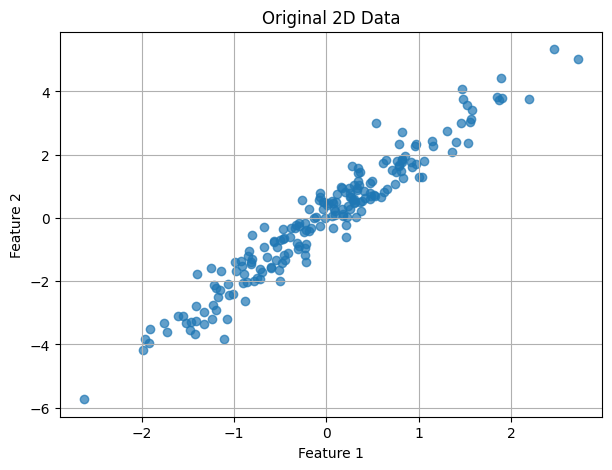

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Tạo dữ liệu mẫu
np.random.seed(42)

x = np.random.normal(0, 1, 200)
y = 2 * x + np.random.normal(0, 0.5, 200)

X = np.column_stack((x, y))

# Vẽ dữ liệu gốc
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original 2D Data")
plt.grid(True)
plt.show()



Dữ liệu trên có dạng kéo dài theo một hướng chéo.  
PCA sẽ cố gắng tìm hướng đó vì đây là hướng có variance lớn nhất.


In [2]:

# Chuẩn hoá dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Áp dụng PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nPrincipal components:")
print(pca.components_)


Explained variance ratio:
[0.98422279 0.01577721]

Principal components:
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]



Kết quả `explained_variance_ratio_` cho biết PC1 và PC2 giữ bao nhiêu phần trăm thông tin.

Thông thường với dữ liệu có xu hướng nằm trên một đường chéo rõ ràng, **PC1 sẽ giữ phần lớn thông tin**.


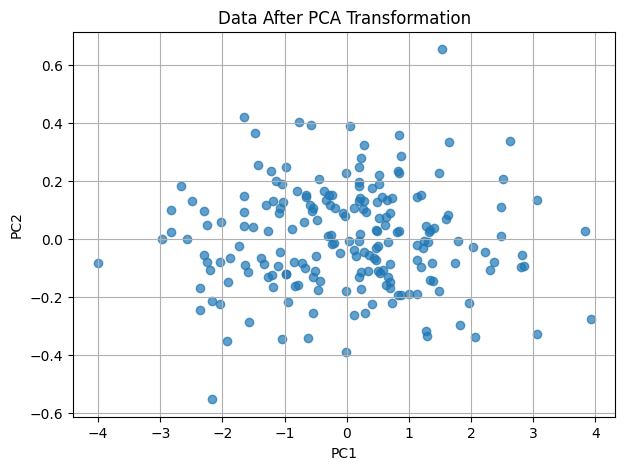

In [3]:

# Vẽ dữ liệu sau PCA
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data After PCA Transformation")
plt.grid(True)
plt.show()



# 13. Demo 2: PCA với Iris Dataset

Bây giờ ta dùng dataset thật có sẵn trong sklearn: **Iris Dataset**.

Dataset này có 4 features:

```text
sepal length
sepal width
petal length
petal width
```

Ta sẽ dùng PCA để giảm từ 4 features xuống 2 principal components.


In [4]:

from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].map({i: name for i, name in enumerate(target_names)})

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:

# Kiểm tra shape dữ liệu
print("Shape of X:", X.shape)
print("Number of features:", X.shape[1])


Shape of X: (150, 4)
Number of features: 4



Dataset Iris có 150 dòng và 4 features.

Mục tiêu của ta:

```text
4 features → PCA → 2 principal components
```


In [6]:

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA: reduce from 4 features to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["target"] = y
df_pca["species"] = df_pca["target"].map({i: name for i, name in enumerate(target_names)})

df_pca.head()


,PC1,PC2,target,species
0,-2.264703,0.480027,0,setosa
1,-2.080961,-0.674134,0,setosa
2,-2.364229,-0.341908,0,setosa
3,-2.299384,-0.597395,0,setosa
4,-2.389842,0.646835,0,setosa


In [7]:

# Explained variance
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal information kept:")
print(pca.explained_variance_ratio_.sum())


Explained variance ratio:
[0.72962445 0.22850762]

Total information kept:
0.9581320720000166



Nếu tổng explained variance của PC1 và PC2 cao, nghĩa là ta đã giảm từ 4 features xuống 2 components nhưng vẫn giữ được phần lớn thông tin.


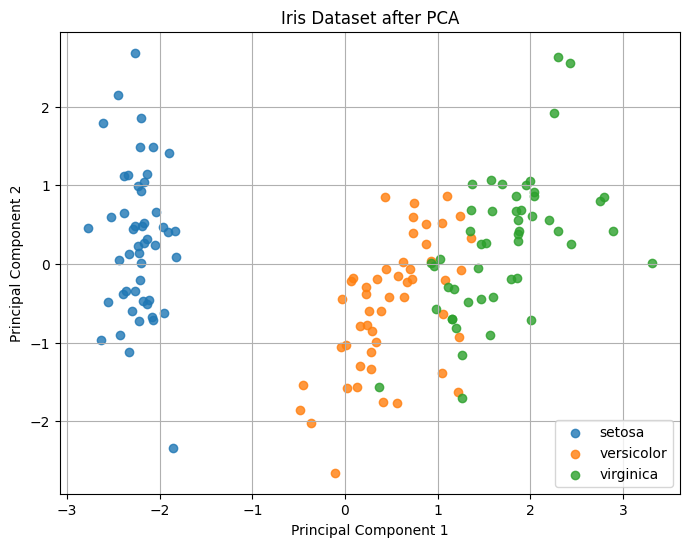

In [8]:

# Visualize PCA result
plt.figure(figsize=(8, 6))

for target_value, species_name in enumerate(target_names):
    subset = df_pca[df_pca["target"] == target_value]
    plt.scatter(subset["PC1"], subset["PC2"], label=species_name, alpha=0.8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset after PCA")
plt.legend()
plt.grid(True)
plt.show()



# 14. Cách chọn số components

Có 2 cách phổ biến để chọn số components.

## Cách 1: Chọn số components cố định

Ví dụ:

```python
PCA(n_components=2)
```

Dùng khi bạn muốn giảm dữ liệu xuống 2D để vẽ biểu đồ.

## Cách 2: Chọn theo tỷ lệ thông tin muốn giữ lại

Ví dụ:

```python
PCA(n_components=0.95)
```

Nghĩa là PCA tự chọn số components sao cho giữ lại khoảng 95% thông tin.


In [9]:

# PCA giữ 95% thông tin
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of components selected:", X_pca_95.shape[1])
print("Explained variance ratio:", pca_95.explained_variance_ratio_)
print("Total information kept:", pca_95.explained_variance_ratio_.sum())


Original number of features: 4
Number of components selected: 2
Explained variance ratio: [0.72962445 0.22850762]
Total information kept: 0.9581320720000166



# 15. Explained Variance Plot

Ta có thể vẽ biểu đồ explained variance để xem mỗi principal component giữ bao nhiêu thông tin.


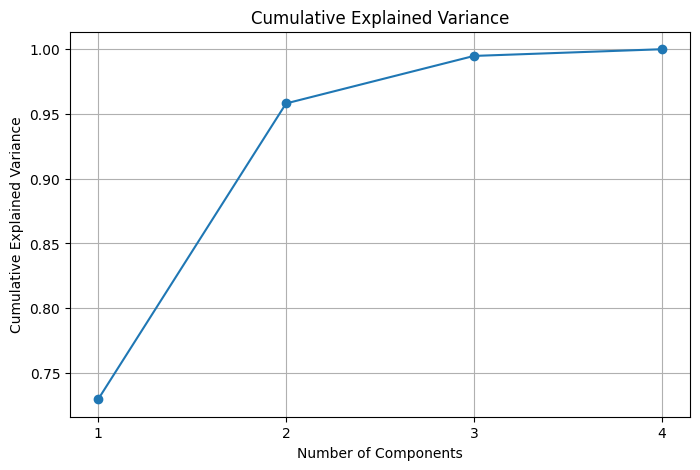

Cumulative explained variance:
1 component(s): 0.7296
2 component(s): 0.9581
3 component(s): 0.9948
4 component(s): 1.0000


In [10]:

# PCA với đầy đủ components
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.show()

print("Cumulative explained variance:")
for i, value in enumerate(cumulative_variance, start=1):
    print(f"{i} component(s): {value:.4f}")



Cách đọc biểu đồ:

- Trục X: số lượng components.
- Trục Y: tổng lượng thông tin được giữ lại.
- Nếu đường cong tăng chậm lại, nghĩa là thêm components mới không giúp giữ thêm nhiều thông tin.

Trong thực tế, ta thường chọn số components sao cho giữ khoảng:

```text
90% - 95% explained variance
```



# 16. Demo 3: PCA kết hợp với Logistic Regression

Bây giờ ta thử dùng PCA trong một Machine Learning pipeline.

Quy trình:

```text
Raw Data
→ StandardScaler
→ PCA
→ Logistic Regression
→ Evaluate Accuracy
```

Lưu ý: Với dataset nhỏ như Iris, PCA không phải lúc nào cũng làm accuracy tốt hơn.  
Mục tiêu demo này là để hiểu cách PCA được đặt trong pipeline.


In [11]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline không dùng PCA
pipeline_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_no_pca.fit(X_train, y_train)
y_pred_no_pca = pipeline_no_pca.predict(X_test)

accuracy_no_pca = accuracy_score(y_test, y_pred_no_pca)

print("Accuracy without PCA:", accuracy_no_pca)


Accuracy without PCA: 0.9333333333333333


In [12]:

# Pipeline có PCA
pipeline_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_with_pca.fit(X_train, y_train)
y_pred_with_pca = pipeline_with_pca.predict(X_test)

accuracy_with_pca = accuracy_score(y_test, y_pred_with_pca)

print("Accuracy with PCA:", accuracy_with_pca)


Accuracy with PCA: 0.9


In [13]:

print("Classification report with PCA:")
print(classification_report(y_test, y_pred_with_pca, target_names=target_names))


Classification report with PCA:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30




# 17. Khi nào nên dùng PCA?

PCA phù hợp khi:

- Dataset có nhiều features.
- Nhiều features có tương quan với nhau.
- Bạn muốn visualize dữ liệu nhiều chiều.
- Bạn muốn giảm noise.
- Bạn muốn tăng tốc training.
- Bạn muốn dùng trước các thuật toán như K-means, SVM, Logistic Regression.

Ví dụ:

```text
Customer Segmentation:
Nhiều thông tin khách hàng → PCA → K-means clustering
```

```text
Image Compression:
Nhiều pixels → PCA → giữ phần chính của ảnh
```

```text
Finance:
Nhiều biến tài chính → PCA → tìm các risk factors chính
```



# 18. Khi nào không nên dùng PCA?

Không nên dùng PCA nếu:

- Bạn cần giải thích rõ từng feature gốc.
- Dataset có ít features.
- Features gốc đã rất quan trọng và dễ hiểu.
- Quan hệ trong dữ liệu không phải tuyến tính.
- Bạn chọn quá ít components làm mất thông tin quan trọng.

Nói thẳng: PCA mạnh, nhưng không phải cây đũa thần.  
Nó giúp dữ liệu gọn hơn, nhưng đổi lại là khó giải thích hơn.



# 19. Ưu điểm của PCA

## Ưu điểm

- Giảm số chiều dữ liệu.
- Giúp visualize dữ liệu.
- Giảm noise.
- Tăng tốc model.
- Giúp xử lý dữ liệu có nhiều features liên quan nhau.
- Hữu ích trước clustering như K-means.

# 20. Nhược điểm của PCA

## Nhược điểm

- Khó giải thích vì components không còn là features gốc.
- Cần chuẩn hoá dữ liệu trước.
- Chỉ bắt tốt quan hệ tuyến tính.
- Có thể làm mất thông tin nếu chọn quá ít components.
- Không phải lúc nào cũng làm model tốt hơn.



# 21. Tóm tắt PCA

Nhớ các ý chính:

```text
PCA = kỹ thuật giảm chiều dữ liệu
```

```text
Principal Component = feature mới tạo từ features gốc
```

```text
PC1 giữ nhiều thông tin nhất
```

```text
Explained Variance = phần trăm thông tin được giữ lại
```

```text
PCA cần Standardization trước khi chạy
```

Quy trình chuẩn:

```text
Data → StandardScaler → PCA → Model / Visualization
```

Các công thức quan trọng:

$$
z = \frac{x - \mu}{\sigma}
$$

$$
Cov(X,Y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
$$

$$
A\vec{v} = \lambda\vec{v}
$$

$$
Explained\ Variance\ Ratio = \frac{\lambda_i}{\sum_{j=1}^{p}\lambda_j}
$$



# 22. Bài tập luyện tập

## Bài 1

Một dataset có 20 features. Sau khi dùng PCA, bạn chọn 5 components và giữ được 92% explained variance.

Hỏi:

1. Dữ liệu đã được giảm từ bao nhiêu chiều xuống bao nhiêu chiều?
2. 92% explained variance nghĩa là gì?
3. Có nên dùng 5 components này không?

---

## Bài 2

Bạn có dataset khách hàng gồm:

```text
Age
Income
Annual Spending
Purchase Frequency
Website Time
App Usage
Discount Usage
```

Hãy trả lời:

1. PCA có thể dùng trong bài toán này không?
2. Sau PCA, có nên dùng K-means không?
3. Vì sao cần chuẩn hoá dữ liệu trước PCA?

---

## Bài 3

Trong Iris Dataset, hãy thử thay đổi:

```python
PCA(n_components=2)
```

thành:

```python
PCA(n_components=3)
```

Sau đó so sánh:

1. Explained variance có tăng không?
2. Visualization 2D còn dùng được không?
3. Accuracy của Logistic Regression có thay đổi không?

---

## Bài 4

Hãy dùng PCA với:

```python
PCA(n_components=0.90)
PCA(n_components=0.95)
PCA(n_components=0.99)
```

Sau đó so sánh số components được PCA chọn.



# 23. Đáp án gợi ý

## Bài 1

1. Dữ liệu giảm từ 20 chiều xuống 5 chiều.
2. 92% explained variance nghĩa là 5 components giữ lại khoảng 92% thông tin của dữ liệu gốc.
3. Có thể dùng, vì 92% là mức khá tốt. Tuy nhiên còn tuỳ bài toán thực tế.

## Bài 2

1. Có thể dùng PCA vì dataset có nhiều features và các features có thể liên quan với nhau.
2. Có thể dùng PCA trước K-means để giảm chiều và giảm noise.
3. Vì PCA bị ảnh hưởng bởi scale. Nếu không chuẩn hoá, biến có giá trị lớn như Income có thể chi phối kết quả PCA.

## Bài 3

1. Explained variance thường sẽ tăng khi tăng số components.
2. Visualization 2D không còn trực tiếp nếu dùng 3 components, trừ khi chỉ vẽ PC1 và PC2.
3. Accuracy có thể tăng, giảm hoặc không đổi tuỳ dữ liệu.

## Bài 4

Khi yêu cầu giữ nhiều thông tin hơn, PCA thường cần nhiều components hơn.

Ví dụ:

```text
90% variance → ít components hơn
95% variance → nhiều components hơn
99% variance → nhiều components nhất
```



# 24. Ghi nhớ cuối bài

PCA giống như việc bạn nén một bài học dài thành bản note ngắn:

- Nếu note tốt, bạn vẫn giữ được ý chính.
- Nếu note quá ngắn, bạn mất thông tin quan trọng.
- Nếu note quá dài, việc giảm chiều không còn nhiều ý nghĩa.

Trong Machine Learning, PCA là công cụ rất hữu ích, nhưng phải dùng đúng lúc.
